# Case Study Assessment — NYC Airbnb Data Preprocessing
### Student Name:ABHAY KRISHNA.V
### Date: 30-09-2025

This notebook is your submission template. Fill in each section — do not delete the headers. Use markdown cells for your written justifications, right next to the code that supports them.

In [129]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/erkansirin78/datasets/master/AB_NYC_2019.csv"
df = pd.read_csv(url)
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


---
## Part 1 — Data Understanding & Quality Audit

In [130]:
# TODO: shape, dtypes, missing value summary
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [131]:
df.isna().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [132]:
# TODO: check for values that are technically present but don't make real-world sense
df.describe()


,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [133]:
# TODO: duplicate check
df[df.duplicated()]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365


**Written notes — what did you find, and what looks suspicious?**

Price has a minimum of 0 and a maximum of 10,000. Minimum nights has a very high maximum of 1,250 days

---
## Part 2 — Missing Value Diagnosis & Treatment

In [134]:
# TODO: investigate missingness pattern(s) across columns

In [135]:
df.isna().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [136]:
df.isnull().mean() * 100

,0
id,0.000000
name,0.032723
host_id,0.000000
host_name,0.042949
neighbourhood_group,0.000000
neighbourhood,0.000000
latitude,0.000000
longitude,0.000000
room_type,0.000000
price,0.000000


**Written justification — MCAR / MAR / MNAR classification per column, and your reasoning:**

_Your answer here._

In [137]:
# TODO: apply your chosen treatment(s)
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)
df["reviews_per_month"].isnull().sum()

np.int64(0)

In [138]:
df = df.drop(columns=["id","name",'host_id',"host_name","last_review"])
df

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...
48890,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,0.00,2,9
48891,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,0.00,2,36
48892,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,0.00,1,27
48893,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,0.00,6,2


In [139]:
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             48895 non-null  object 
 1   neighbourhood                   48895 non-null  object 
 2   latitude                        48895 non-null  float64
 3   longitude                       48895 non-null  float64
 4   room_type                       48895 non-null  object 
 5   price                           48895 non-null  int64  
 6   minimum_nights                  48895 non-null  int64  
 7   number_of_reviews               48895 non-null  int64  
 8   reviews_per_month               48895 non-null  float64
 9   calculated_host_listings_count  48895 non-null  int64  
 10  availability_365                48895 non-null  int64  
dtypes: float64(3), int64(5), object(3)
memory usage: 4.1+ MB


,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0
minimum_nights,0
number_of_reviews,0
reviews_per_month,0
calculated_host_listings_count,0


**Written justification — why this treatment for each column, and what you'd risk with `dropna()` instead:**

_Your answer here._

---
## Part 3 — Outlier Detection & Treatment

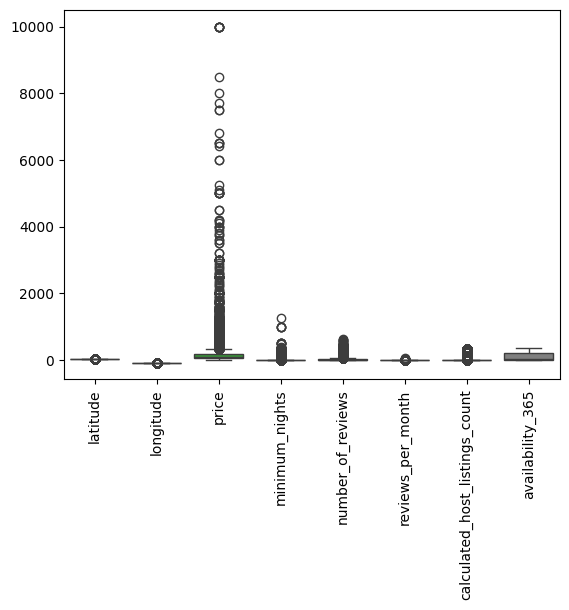

In [140]:
# TODO: detect outliers in at least two numeric columns
sns.boxplot(df)
plt.xticks(rotation=90)
plt.show()

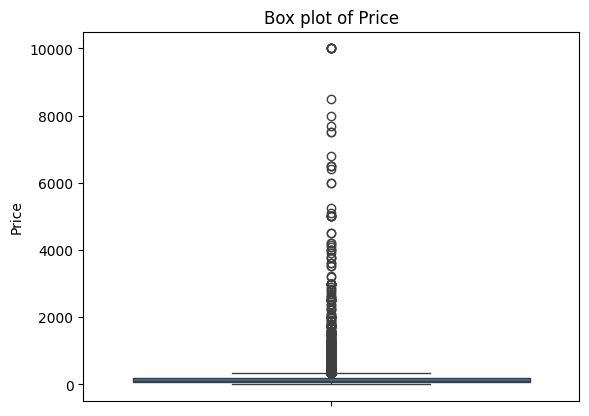

In [141]:
sns.boxplot(y=df['price'])
plt.title('Box plot of Price')
plt.ylabel('Price')
plt.show()


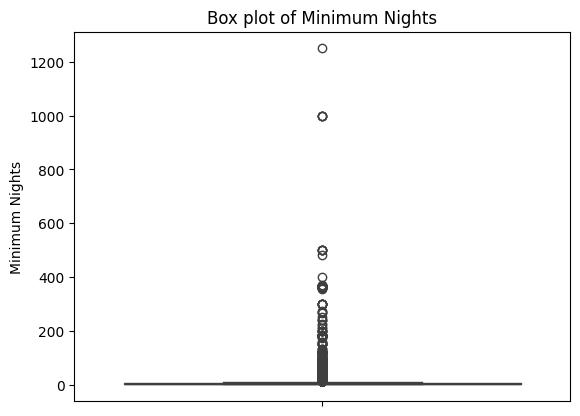

In [142]:
sns.boxplot(y=df['minimum_nights'])
plt.title('Box plot of Minimum Nights')
plt.ylabel('Minimum Nights')
plt.show()

**Written justification — for each outlier group, is it an error or a genuine listing? What evidence supports your call?**

_Your answer here._

In [143]:
# TODO: apply treatment consistent with your judgment above


In [144]:
Q1_price = df['price'].quantile(0.25)
Q3_price = df['price'].quantile(0.75)
IQR_price = Q3_price - Q1_price

lower_bound_price = Q1_price - 1.5 * IQR_price
upper_bound_price = Q3_price + 1.5 * IQR_price

Q1_min_nights = df['minimum_nights'].quantile(0.25)
Q3_min_nights = df['minimum_nights'].quantile(0.75)
IQR_min_nights = Q3_min_nights - Q1_min_nights

lower_bound_min_nights = Q1_min_nights - 1.5 * IQR_min_nights
upper_bound_min_nights = Q3_min_nights + 1.5 * IQR_min_nights

df = df[((df['price'] >= lower_bound_price) & (df['price'] <= upper_bound_price)) & \
                ((df['minimum_nights'] >= lower_bound_min_nights) & (df['minimum_nights'] <= upper_bound_min_nights))]

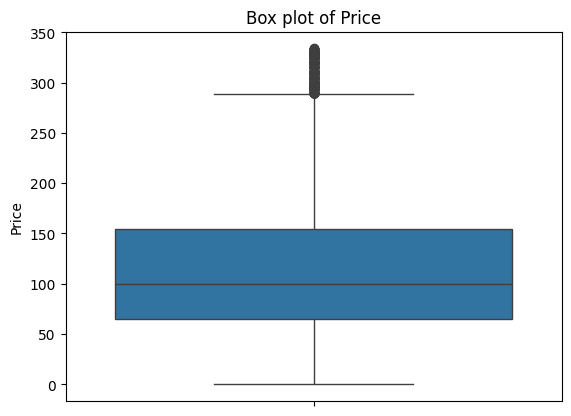

In [145]:
sns.boxplot(y=df['price'])
plt.title('Box plot of Price')
plt.ylabel('Price')
plt.show()

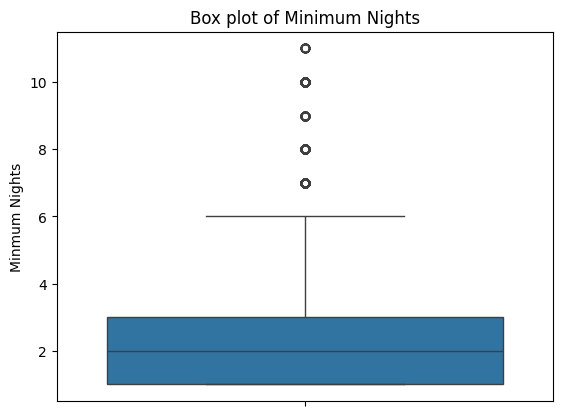

In [146]:
sns.boxplot(y=df['minimum_nights'])
plt.title('Box plot of Minimum Nights')
plt.ylabel('Minmum Nights')
plt.show()

---
## Part 4 — Feature Engineering & Encoding

In [147]:
# TODO: encode categorical columns appropriately

In [148]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39738 entries, 0 to 48894
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             39738 non-null  object 
 1   neighbourhood                   39738 non-null  object 
 2   latitude                        39738 non-null  float64
 3   longitude                       39738 non-null  float64
 4   room_type                       39738 non-null  object 
 5   price                           39738 non-null  int64  
 6   minimum_nights                  39738 non-null  int64  
 7   number_of_reviews               39738 non-null  int64  
 8   reviews_per_month               39738 non-null  float64
 9   calculated_host_listings_count  39738 non-null  int64  
 10  availability_365                39738 non-null  int64  
dtypes: float64(3), int64(5), object(3)
memory usage: 3.6+ MB


In [149]:
df['neighbourhood_group'].unique()

array(['Brooklyn', 'Manhattan', 'Queens', 'Staten Island', 'Bronx'],
      dtype=object)

In [150]:
df = pd.get_dummies(df, columns=['neighbourhood_group'],dtype = 'int')
df.head()

,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island
0,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365,0,1,0,0,0
1,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,0,0,1,0,0
2,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365,0,0,1,0,0
3,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194,0,1,0,0,0
4,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0,0,0,1,0,0


In [151]:
df['neighbourhood'].unique()

array(['Kensington', 'Midtown', 'Harlem', 'Clinton Hill', 'East Harlem',
       'Murray Hill', "Hell's Kitchen", 'Upper West Side', 'Chinatown',
       'South Slope', 'Williamsburg', 'Fort Greene', 'Chelsea',
       'Crown Heights', 'Park Slope', 'Bedford-Stuyvesant',
       'Windsor Terrace', 'Inwood', 'Greenpoint', 'Bushwick', 'Flatbush',
       'Lower East Side', 'East Village', 'Long Island City', 'Kips Bay',
       'Upper East Side', 'Washington Heights', 'Prospect Heights',
       'Carroll Gardens', 'Prospect-Lefferts Gardens', 'Flatlands',
       'Cobble Hill', 'Flushing', 'West Village', 'DUMBO', 'Gowanus',
       'St. George', 'Highbridge', 'Financial District',
       'Morningside Heights', 'Jamaica', 'Ridgewood', 'Middle Village',
       'NoHo', 'Ditmars Steinway', 'Flatiron District',
       'Roosevelt Island', 'Greenwich Village', 'Little Italy',
       'East Flatbush', 'Tompkinsville', 'Astoria', 'Clason Point',
       'Eastchester', 'Boerum Hill', 'Brooklyn Heights', 'Tw

In [152]:
pip install category_encoders

In [153]:
import category_encoders as ce


target_encoder = ce.TargetEncoder(cols=['neighbourhood'])
df['neighbourhood'] = target_encoder.fit_transform(df['neighbourhood'], df['price'])


In [154]:
df

,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island
0,87.927689,40.64749,-73.97237,Private room,149,1,9,0.21,6,365,0,1,0,0,0
1,178.863132,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,0,0,1,0,0
2,104.819408,40.80902,-73.94190,Private room,150,3,0,0.00,1,365,0,0,1,0,0
3,125.760684,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194,0,1,0,0,0
4,114.538304,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,96.194016,40.67853,-73.94995,Private room,70,2,0,0.00,2,9,0,1,0,0,0
48891,81.895030,40.70184,-73.93317,Private room,40,4,0,0.00,2,36,0,1,0,0,0
48892,104.819408,40.81475,-73.94867,Entire home/apt,115,10,0,0.00,1,27,0,0,1,0,0
48893,160.006307,40.75751,-73.99112,Shared room,55,1,0,0.00,6,2,0,0,1,0,0


In [155]:
df['room_type'].unique()

array(['Private room', 'Entire home/apt', 'Shared room'], dtype=object)

In [156]:
from sklearn.preprocessing import OrdinalEncoder
encoder_room_type = OrdinalEncoder(categories= [['Entire home/apt', 'Private room', 'Shared room']]
)
df['room_type'] = encoder_room_type.fit_transform(df[['room_type']])
df

,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island
0,87.927689,40.64749,-73.97237,1.0,149,1,9,0.21,6,365,0,1,0,0,0
1,178.863132,40.75362,-73.98377,0.0,225,1,45,0.38,2,355,0,0,1,0,0
2,104.819408,40.80902,-73.94190,1.0,150,3,0,0.00,1,365,0,0,1,0,0
3,125.760684,40.68514,-73.95976,0.0,89,1,270,4.64,1,194,0,1,0,0,0
4,114.538304,40.79851,-73.94399,0.0,80,10,9,0.10,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,96.194016,40.67853,-73.94995,1.0,70,2,0,0.00,2,9,0,1,0,0,0
48891,81.895030,40.70184,-73.93317,1.0,40,4,0,0.00,2,36,0,1,0,0,0
48892,104.819408,40.81475,-73.94867,0.0,115,10,0,0.00,1,27,0,0,1,0,0
48893,160.006307,40.75751,-73.99112,2.0,55,1,0,0.00,6,2,0,0,1,0,0


In [157]:
# TODO: engineer at least two new features


In [158]:

# Percentage of the year the listing is available

df["availability_ratio"] = df["availability_365"] / 365
df.head()

,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,availability_ratio
0,87.927689,40.64749,-73.97237,1.0,149,1,9,0.21,6,365,0,1,0,0,0,1.000000
1,178.863132,40.75362,-73.98377,0.0,225,1,45,0.38,2,355,0,0,1,0,0,0.972603
2,104.819408,40.80902,-73.94190,1.0,150,3,0,0.00,1,365,0,0,1,0,0,1.000000
3,125.760684,40.68514,-73.95976,0.0,89,1,270,4.64,1,194,0,1,0,0,0,0.531507
4,114.538304,40.79851,-73.94399,0.0,80,10,9,0.10,1,0,0,0,1,0,0,0.000000


In [159]:
# Whether the listing has received at least one review

df["has_reviews"] = (df["number_of_reviews"] > 0).astype(int)
df.head()

,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,availability_ratio,has_reviews
0,87.927689,40.64749,-73.97237,1.0,149,1,9,0.21,6,365,0,1,0,0,0,1.000000,1
1,178.863132,40.75362,-73.98377,0.0,225,1,45,0.38,2,355,0,0,1,0,0,0.972603,1
2,104.819408,40.80902,-73.94190,1.0,150,3,0,0.00,1,365,0,0,1,0,0,1.000000,0
3,125.760684,40.68514,-73.95976,0.0,89,1,270,4.64,1,194,0,1,0,0,0,0.531507,1
4,114.538304,40.79851,-73.94399,0.0,80,10,9,0.10,1,0,0,0,1,0,0,0.000000,1


**Written justification — why these features, and which column(s) should NOT be used to predict price, and why:**

number_of_reviews and reviews_per_month should not be used as predictors when estimating the price of a new listing because they depend on information collected after guests have interacted with the listing. Using these variables could give the model information that would not be available at prediction time

---
## Part 5 — Build a Reusable Preprocessing Pipeline

In [160]:
# TODO: train/test split (before fitting anything)


In [161]:
pip install category_encoders

In [162]:
import pandas as pd

import category_encoders as ce
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [163]:
url = "https://raw.githubusercontent.com/erkansirin78/datasets/master/AB_NYC_2019.csv"
df = pd.read_csv(url)
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [168]:
Q1_price = df['price'].quantile(0.25)
Q3_price = df['price'].quantile(0.75)
IQR_price = Q3_price - Q1_price

lower_bound_price = Q1_price - 1.5 * IQR_price
upper_bound_price = Q3_price + 1.5 * IQR_price

Q1_min_nights = df['minimum_nights'].quantile(0.25)
Q3_min_nights = df['minimum_nights'].quantile(0.75)
IQR_min_nights = Q3_min_nights - Q1_min_nights

lower_bound_min_nights = Q1_min_nights - 1.5 * IQR_min_nights
upper_bound_min_nights = Q3_min_nights + 1.5 * IQR_min_nights

df = df[((df['price'] >= lower_bound_price) & (df['price'] <= upper_bound_price)) & \
                ((df['minimum_nights'] >= lower_bound_min_nights) & (df['minimum_nights'] <= upper_bound_min_nights))]

In [169]:
X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [170]:
categorical_col_1 = ['neighbourhood_group']
categorical_col_2 = ['room_type']
categorical_col_3 = ['neighbourhood']

numerical_cols = [
    'latitude', 'longitude', 'minimum_nights', 'number_of_reviews',
    'reviews_per_month', 'calculated_host_listings_count', 'availability_365',
     ]

In [ ]:
# combine pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_col_1),
        ('ordinal', OrdinalEncoder(categories=[['Entire home/apt', 'Private room','Shared room']]), categorical_col_2),
        ('target', ce.TargetEncoder(cols=categorical_col_3), categorical_col_3)
    ])

In [171]:
# preprocessing pipeline
preprocessing_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor) # Then, apply different preprocessing steps using ColumnTransformer
])

In [175]:
# Fit and transform the training data
X_train_psd = preprocessing_pipeline.fit_transform(X_train, y_train)
X_test_psd = preprocessing_pipeline.transform(X_test)

In [176]:
X_train_psd

array([[-8.72864616e-02, -9.81099650e-01, -3.74734426e-01, ...,
         0.00000000e+00,  0.00000000e+00,  1.69660695e+02],
       [-1.46942391e-01, -2.44291946e-01,  1.61106137e-01, ...,
         0.00000000e+00,  1.00000000e+00,  1.24544068e+02],
       [ 1.47881445e+00, -1.28174916e-01,  1.23278726e+00, ...,
         0.00000000e+00,  0.00000000e+00,  1.07348548e+02],
       ...,
       [-9.82833487e-01,  1.20244646e+00, -3.74734426e-01, ...,
         0.00000000e+00,  0.00000000e+00,  8.78253154e+01],
       [ 3.50485389e-01, -1.00314719e+00,  6.96946701e-01, ...,
         0.00000000e+00,  0.00000000e+00,  1.75224919e+02],
       [-9.98549215e-02, -9.76480166e-01, -3.74734426e-01, ...,
         0.00000000e+00,  0.00000000e+00,  1.69660695e+02]])

In [178]:
X_test_psd

array([[-4.73545329e-01,  5.74826564e-01,  6.96946701e-01, ...,
         0.00000000e+00,  1.00000000e+00,  8.23700696e+01],
       [-2.77937607e-01, -2.03976449e-01, -3.74734426e-01, ...,
         0.00000000e+00,  1.00000000e+00,  1.24544068e+02],
       [-7.22436239e-01, -3.00145708e-01, -3.74734426e-01, ...,
         0.00000000e+00,  1.00000000e+00,  1.25639037e+02],
       ...,
       [-6.01531195e-01, -1.97677153e-01, -3.74734426e-01, ...,
         0.00000000e+00,  0.00000000e+00,  9.62161316e+01],
       [ 1.16495700e+00, -4.46499361e-01, -3.74734426e-01, ...,
         0.00000000e+00,  1.00000000e+00,  1.46613250e+02],
       [ 3.00781713e-02, -7.30177676e-01,  1.23278726e+00, ...,
         0.00000000e+00,  0.00000000e+00,  1.51942997e+02]])

---
## Part 6 — Written Reflection

1.Data Leakage:Fitting transformers only on X_train prevents test set statistics (like mean or target averages) from leaking into training, avoiding overly optimistic results.

2.Encoding Strategy:
One-Hot: Best for low-cardinality nominal features (neighbourhood_group); avoids false ordering, but increases dimensionality on high-cardinality data.

Target Encoding: Best for high-cardinality features (neighbourhood) to keep dimensions low, but risks overfitting without proper fold fitting.

Ordinal: Best for ordered categories (room_type), but creates false mathematical relationships on unordered features.

3.Post-Listing Risks & Deployment:
Features like reviews_per_month don't exist for new listings, causing temporal leakage. Real-world deployment also faces concept drift and noisy user data, requiring ongoing data validation and model retraining.